# 1 Sobol analysis with UQPyLab

## 1.0 Connecting to UQ[py]Lab

Execute the following cell to connect to UQpyLab.

In [1]:
from uqpylab import sessions
import numpy as np
import matplotlib.pyplot as plt

The following cell needs to be executed only once. You find your token in your profile on the UQ[py]Lab website: https://uqpylab.uq-cloud.io/

In [2]:
# myToken = '49761b4534b3f8c1b8b812cee30a00103da387cd' # REPLACE THIS WITH YOUR TOKEN
# UQCloud_instance = 'https://uqcloud.ethz.ch' # The UQCloud instance to use
# # Start the session
# mySession = sessions.cloud(host=UQCloud_instance, token=myToken, force_restart=True)
# # Get a convenient handle to the command line interface
# uq = mySession.cli
# mySession.save_config() # to save and restore the session later

In the future, you can uncomment and execute the following cell to connect to UQ[py]Lab.

In [3]:
# Start the session
mySession = sessions.cloud()
# Get a convenient handle to the command line interface
uq = mySession.cli
# Reset the session
mySession.reset()

Processing .. done!

 uqpylab.sessions :: INFO     :: This is UQ[py]Lab, version 1.0, running on https://uqcloud.ethz.ch. 
                                 UQ[py]Lab is free software, published under the open source BSD 3-clause license.
                                 To request special permissions, please contact:
                                  - Stefano Marelli (marelli@ibk.baug.ethz.ch).
                                 A new session (0ce3a58f10904b77b76db7879c6b9137) started.
 uqpylab.sessions :: INFO     :: Reset successful.


In [4]:
# Set the random seed for reproducibility
uq.rng(101,'twister');

## 1.1 Define model and input: Flood model

In [5]:
# Define the model properties
ModelOpts = {
    'Type': 'Model', 
    'ModelFun':'flood.model'
}

# Create the model
myModel = uq.createModel(ModelOpts)

In [6]:
# Define the marginal properties
InputOpts = {
    'Marginals': [
        {
            'Name': 'Q',
            'Type': 'Gumbel',
            'Parameters': [1013, 558],
            'Bounds': [500, 3000]
        },
        {
            'Name':'Ks',
            'Type': 'Gaussian',
            'Parameters': [30, 8],
            'Bounds': [15, 1e12]
        },
        {
            'Name': 'Zv',
            'Type': 'Triangular',
            'Parameters': [49, 50, 51]
        },
        {
            'Name': 'Zm',
            'Type': 'Triangular',
            'Parameters': [54, 55, 56]
        },
        {
            'Name': 'Hd',
            'Type': 'Uniform',
            'Parameters': [7, 9]
        },
        {
            'Name': 'Cb',
            'Type': 'Triangular',
            'Parameters': [55, 55.5, 56]
        },
        {
            'Name': 'L',
            'Type': 'Triangular',
            'Parameters': [4990, 5000, 5010]
        },
        {
            'Name': 'B',
            'Type': 'Triangular',
            'Parameters': [295, 300, 305]
        }]
}

# Create the input
myInput = uq.createInput(InputOpts)

In [7]:
Xtest = uq.getSample(myInput, 10)
Ytest = uq.evalModel(myModel, Xtest)
print(Ytest)

[[0.66972776]
 [0.67522649]
 [0.65174526]
 [0.66689982]
 [0.65021196]
 [0.72811519]
 [0.66660116]
 [0.69834902]
 [0.67838175]
 [0.64970498]]


## 1.2 Sobol' indices with UQ[py]Lab
We can let UQ[py]Lab compute the Sobol indices. It uses the Pick-and-Freeze estimator introduced in *Janon, A., T. Klein, A. Lagnoux, M. Nodet, and C. Prieur (2014): Asymptotic normality and efficiency of two Sobol’ index estimators.*

In [8]:
SobolOpts = {
    'Type': 'Sensitivity',
    'Method': 'Sobol',
    'Model': myModel["Name"]
}
SobolOpts['Sobol'] = {
    'SampleSize': 1e3
}

Note that the total cost of computation is $(d+2)\times N$, where $d$ is the input dimension and $N$ is the sample size. Therefore, the total cost for the current setup is $(8+2)\times N=10N$ evaluations of the full computational model.

 uqpylab.sessions :: INFO     :: Received intermediate compute request, function: flood.model.
 uqpylab.sessions :: INFO     :: Carrying out local computation...
 uqpylab.sessions :: INFO     :: Local computation complete.
 uqpylab.sessions :: INFO     :: Starting transmission of intermediate compute results ((10000,))...
 uqpylab.sessions :: INFO     :: Intermediate compute results sent.
--------------------------------------------------
     Total Sobol' indices for output component 1
--------------------------------------------------
Q           Ks          Zv          Zm          Hd          Cb          L           B           
0.566859    0.275678    0.125072    0.007041    0.200408    0.031139    0.000000    0.000133    
--------------------------------------------------
--------------------------------------------------
    First Order Sobol' indices for output component 1
--------------------------------------------------
Q           Ks          Zv          Zm          Hd      

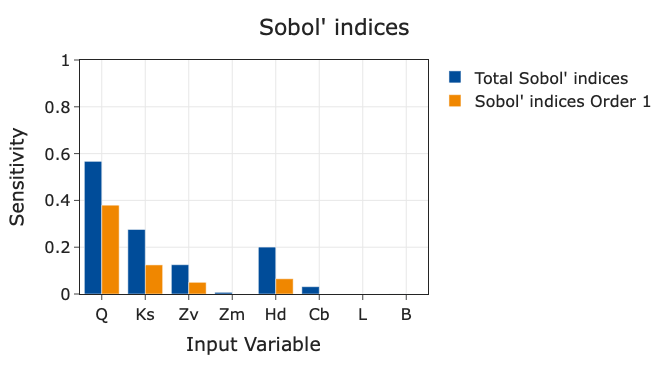

In [9]:
mySobolAnalysisMC = uq.createAnalysis(SobolOpts)
uq.print(mySobolAnalysisMC)
uq.display(mySobolAnalysisMC);

_<b>Related manual:</b> <a href="https://storage.googleapis.com/uqpylab-doc-html/UserManual_Sensitivity.html">UQpyLab User Manual: Sensitivity Analysis</a>_

<div class="alert alert-block alert-success">
    <b>Tasks:</b> 
    <ul>
<li>What can you say about interactions in the model? </li>
<li>By definition, total Sobol indices should not be smaller than first-order indices. Do you notice any problem with the method for small sample sizes (SampleSize = 100)? You might need to re-run the analysis. What does this imply for the analysis of interactions?</li>
<li>How many samples are needed for a stable estimation?</li>
</ul>
    
</div>

## Terminate the remote UQCloud session

In [10]:
mySession.quit()

 uqpylab.sessions :: INFO     :: Session 0ce3a58f10904b77b76db7879c6b9137 terminated.


True